# Student Weekly Usage Metrics
## Comparing Group A vs Group B 

### Number of students (from each group) using the system (weekly)

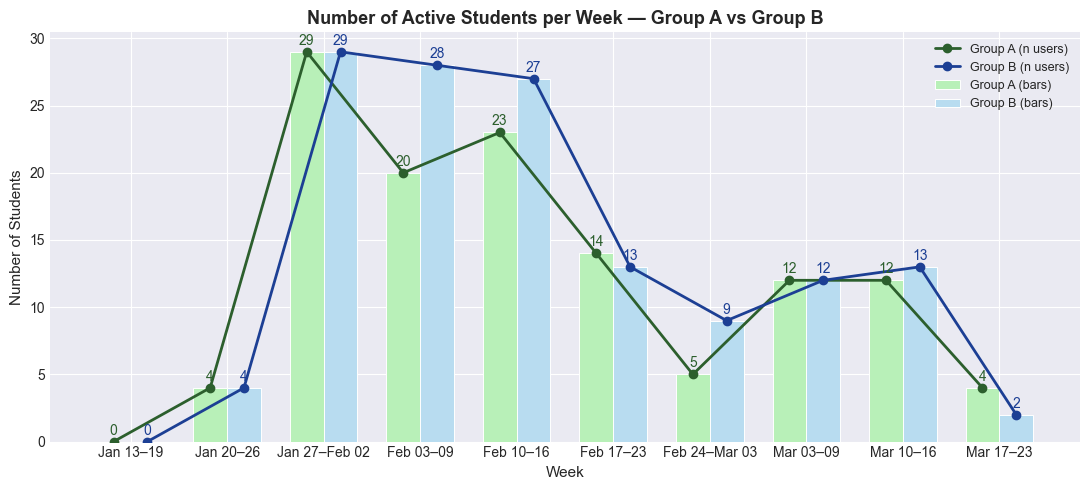

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')

# --- Define your weeks ---
weeks = [
    ('Jan 13–19',     'base_exports/base_usage_20260113_to_20260119.csv',  'db_exports/db_usage_20260113_to_20260119.csv'),
    ('Jan 20–26',     'base_exports/base_usage_20260120_to_20260126.csv',  'db_exports/db_usage_20260120_to_20260126.csv'),
    ('Jan 27–Feb 02', 'base_exports/base_usage_20260127_to_20260202.csv',  'db_exports/db_usage_20260127_to_20260202.csv'),
    ('Feb 03–09',     'base_exports/base_usage_20260203_to_20260209.csv',  'db_exports/db_usage_20260203_to_20260209.csv'),
    ('Feb 10–16',     'base_exports/base_usage_20260210_to_20260216.csv',  'db_exports/db_usage_20260210_to_20260216.csv'),
    ('Feb 17–23',     'base_exports/base_usage_20260217_to_20260223.csv',  'db_exports/db_usage_20260217_to_20260223.csv'),
    ('Feb 24–Mar 03', 'base_exports/base_usage_20260224_to_20260302.csv',  'db_exports/db_usage_20260224_to_20260302.csv'),
    ('Mar 03–09',     'base_exports/base_usage_20260303_to_20260309.csv',  'db_exports/db_usage_20260303_to_20260309.csv'),
    ('Mar 10–16',     'base_exports/base_usage_20260310_to_20260316.csv',  'db_exports/db_usage_20260310_to_20260316.csv'),
    ('Mar 17–23',     'base_exports/base_usage_20260317_to_20260323.csv',  'db_exports/db_usage_20260317_to_20260323.csv'),
]

# --- Colors ---
color_group_a = '#B8F0B8'  # Soft pastel green
color_group_b = '#B8DCF0'  # Soft pastel blue
color_line_a  = '#2C5F2D'  # Dark green
color_line_b  = '#1C3F94'  # Dark blue

# --- Load and count unique students per week ---
records = []
for week_label, path_a, path_b in weeks:
    df_a = pd.read_csv(path_a, encoding='latin-1')
    df_b = pd.read_csv(path_b, encoding='latin-1')
    records.append({
        'week':      week_label,
        'count_a':   df_a['student_email'].nunique(),  # unique students in Group A
        'count_b':   df_b['student_email'].nunique(),  # unique students in Group B
    })

df_plot = pd.DataFrame(records)

# --- Layout ---
week_labels = df_plot['week'].tolist()
x = np.arange(len(week_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

# Grouped bars
bars_a = ax.bar(x - bar_width / 2, df_plot['count_a'], width=bar_width,
                color=color_group_a, edgecolor='white', linewidth=0.7, label='Group A (bars)', zorder=2)
bars_b = ax.bar(x + bar_width / 2, df_plot['count_b'], width=bar_width,
                color=color_group_b, edgecolor='white', linewidth=0.7, label='Group B (bars)', zorder=2)

# Trend lines connecting bar tops
ax.plot(x - bar_width / 2, df_plot['count_a'], color=color_line_a, linewidth=2,
        marker='o', markersize=6, label='Group A (n users)', zorder=3)
ax.plot(x + bar_width / 2, df_plot['count_b'], color=color_line_b, linewidth=2,
        marker='o', markersize=6, label='Group B (n users)', zorder=3)

# Value labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10, color=color_line_a)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10, color=color_line_b)

ax.set_xticks(x)
ax.set_xticklabels(week_labels, fontsize=10)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)
ax.set_title('Number of Active Students per Week — Group A vs Group B', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig('students_by_week.png', dpi=150, bbox_inches='tight')
plt.show()

### Average number of conversations per student (weekly)

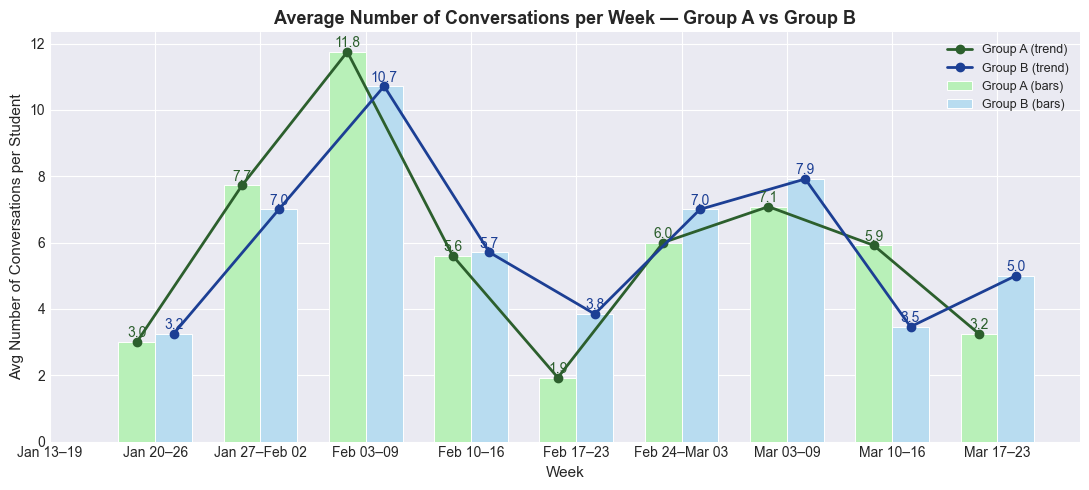

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# --- Define your 5 weeks ---
weeks = [
    ('Jan 13–19',     'base_exports/base_usage_20260113_to_20260119.csv',  'db_exports/db_usage_20260113_to_20260119.csv'),
    ('Jan 20–26',     'base_exports/base_usage_20260120_to_20260126.csv',  'db_exports/db_usage_20260120_to_20260126.csv'),
    ('Jan 27–Feb 02', 'base_exports/base_usage_20260127_to_20260202.csv',  'db_exports/db_usage_20260127_to_20260202.csv'),
    ('Feb 03–09',     'base_exports/base_usage_20260203_to_20260209.csv',  'db_exports/db_usage_20260203_to_20260209.csv'),
    ('Feb 10–16',     'base_exports/base_usage_20260210_to_20260216.csv',  'db_exports/db_usage_20260210_to_20260216.csv'),
    ('Feb 17–23',     'base_exports/base_usage_20260217_to_20260223.csv',  'db_exports/db_usage_20260217_to_20260223.csv'),
    ('Feb 24–Mar 03',     'base_exports/base_usage_20260224_to_20260302.csv',  'db_exports/db_usage_20260224_to_20260302.csv'),
    ('Mar 03–09',     'base_exports/base_usage_20260303_to_20260309.csv',  'db_exports/db_usage_20260303_to_20260309.csv'),
    ('Mar 10–16',     'base_exports/base_usage_20260310_to_20260316.csv',  'db_exports/db_usage_20260310_to_20260316.csv'),
    ('Mar 17–23',     'base_exports/base_usage_20260317_to_20260323.csv',  'db_exports/db_usage_20260317_to_20260323.csv'),
]

# --- Colors (reusing your palette) ---
color_group_a = '#B8F0B8'  # Soft pastel green
color_group_b = '#B8DCF0'  # Soft pastel blue
color_line_a  = '#2C5F2D'  # Dark green line 
color_line_b  = '#1C3F94'  # Dark blue line

# --- Load and aggregate ---
records = []
for week_label, path_a, path_b in weeks:
    df_a = pd.read_csv(path_a, encoding='latin-1')
    df_b = pd.read_csv(path_b, encoding='latin-1')
    records.append({
        'week':    week_label,
        'mean_a':  df_a['total_conv'].mean(),
        'mean_b':  df_b['total_conv'].mean(),
    })

df_plot = pd.DataFrame(records)

# --- Layout ---
week_labels = df_plot['week'].tolist()
x = np.arange(len(week_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

# Grouped bars
bars_a = ax.bar(x - bar_width / 2, df_plot['mean_a'], width=bar_width,
                color=color_group_a, edgecolor='white', linewidth=0.7, label='Group A (bars)', zorder=2)
bars_b = ax.bar(x + bar_width / 2, df_plot['mean_b'], width=bar_width,
                color=color_group_b, edgecolor='white', linewidth=0.7, label='Group B (bars)', zorder=2)

# Trend lines connecting bar tops
ax.plot(x - bar_width / 2, df_plot['mean_a'], color=color_line_a, linewidth=2,
        marker='o', markersize=6, label='Group A (trend)', zorder=3)
ax.plot(x + bar_width / 2, df_plot['mean_b'], color=color_line_b, linewidth=2,
        marker='o', markersize=6, label='Group B (trend)', zorder=3)

# Value labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, color=color_line_a)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, color=color_line_b)

ax.set_xticks(x)
ax.set_xticklabels(week_labels, fontsize=10)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Avg Number of Conversations per Student', fontsize=11)
ax.set_title('Average Number of Conversations per Week — Group A vs Group B', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig('avg_conv_by_week.png', dpi=150, bbox_inches='tight')
plt.show()

### Average messages per conversations (weekly)

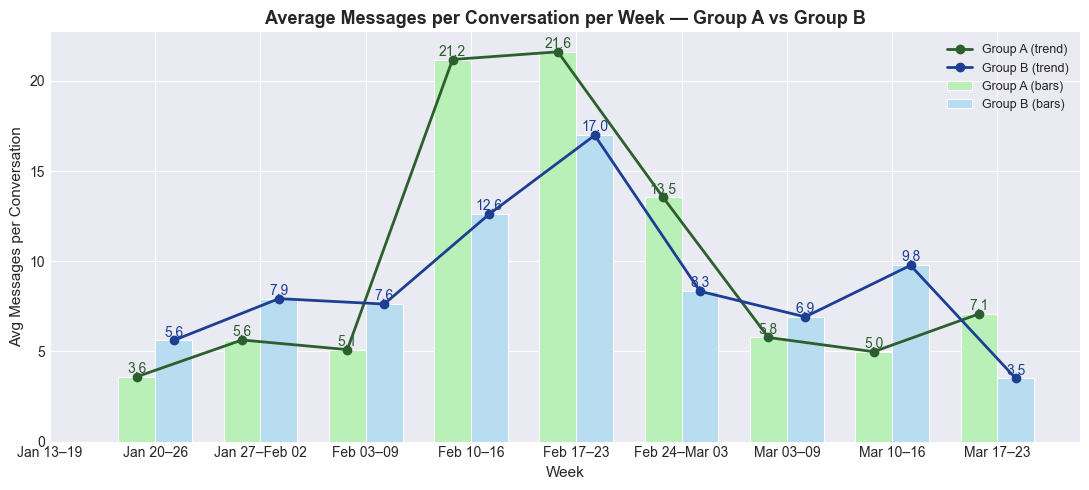

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# --- Define your weeks ---
weeks = [
    ('Jan 13–19',     'base_exports/base_usage_20260113_to_20260119.csv',  'db_exports/db_usage_20260113_to_20260119.csv'),
    ('Jan 20–26',     'base_exports/base_usage_20260120_to_20260126.csv',  'db_exports/db_usage_20260120_to_20260126.csv'),
    ('Jan 27–Feb 02', 'base_exports/base_usage_20260127_to_20260202.csv',  'db_exports/db_usage_20260127_to_20260202.csv'),
    ('Feb 03–09',     'base_exports/base_usage_20260203_to_20260209.csv',  'db_exports/db_usage_20260203_to_20260209.csv'),
    ('Feb 10–16',     'base_exports/base_usage_20260210_to_20260216.csv',  'db_exports/db_usage_20260210_to_20260216.csv'),
    ('Feb 17–23',     'base_exports/base_usage_20260217_to_20260223.csv',  'db_exports/db_usage_20260217_to_20260223.csv'),
    ('Feb 24–Mar 03',     'base_exports/base_usage_20260224_to_20260302.csv',  'db_exports/db_usage_20260224_to_20260302.csv'),
    ('Mar 03–09',     'base_exports/base_usage_20260303_to_20260309.csv',  'db_exports/db_usage_20260303_to_20260309.csv'),
    ('Mar 10–16',     'base_exports/base_usage_20260310_to_20260316.csv',  'db_exports/db_usage_20260310_to_20260316.csv'),
    ('Mar 17–23',     'base_exports/base_usage_20260317_to_20260323.csv',  'db_exports/db_usage_20260317_to_20260323.csv'),
]

# --- Colors ---
color_group_a = '#B8F0B8'  # Soft pastel green
color_group_b = '#B8DCF0'  # Soft pastel blue
color_line_a  = '#2C5F2D'  # Dark green line
color_line_b  = '#1C3F94'  # Dark blue line

# --- Load and aggregate ---
records = []
for week_label, path_a, path_b in weeks:
    df_a = pd.read_csv(path_a, encoding='latin-1')
    df_b = pd.read_csv(path_b, encoding='latin-1')
    records.append({
        'week':   week_label,
        'mean_a': df_a['avg_msg_per_conv'].mean(),  # ← changed
        'mean_b': df_b['avg_msg_per_conv'].mean(),  # ← changed
    })

df_plot = pd.DataFrame(records)

# --- Layout ---
week_labels = df_plot['week'].tolist()
x = np.arange(len(week_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

# Grouped bars
bars_a = ax.bar(x - bar_width / 2, df_plot['mean_a'], width=bar_width,
                color=color_group_a, edgecolor='white', linewidth=0.7, label='Group A (bars)', zorder=2)
bars_b = ax.bar(x + bar_width / 2, df_plot['mean_b'], width=bar_width,
                color=color_group_b, edgecolor='white', linewidth=0.7, label='Group B (bars)', zorder=2)

# Trend lines connecting bar tops
ax.plot(x - bar_width / 2, df_plot['mean_a'], color=color_line_a, linewidth=2,
        marker='o', markersize=6, label='Group A (trend)', zorder=3)
ax.plot(x + bar_width / 2, df_plot['mean_b'], color=color_line_b, linewidth=2,
        marker='o', markersize=6, label='Group B (trend)', zorder=3)

# Value labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, color=color_line_a)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, color=color_line_b)

ax.set_xticks(x)
ax.set_xticklabels(week_labels, fontsize=10)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Avg Messages per Conversation', fontsize=11)                           # ← changed
ax.set_title('Average Messages per Conversation per Week — Group A vs Group B',       # ← changed
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig('avg_msg_per_conv_by_week.png', dpi=150, bbox_inches='tight')             # ← changed
plt.show()

### Average characters per message (weekly)

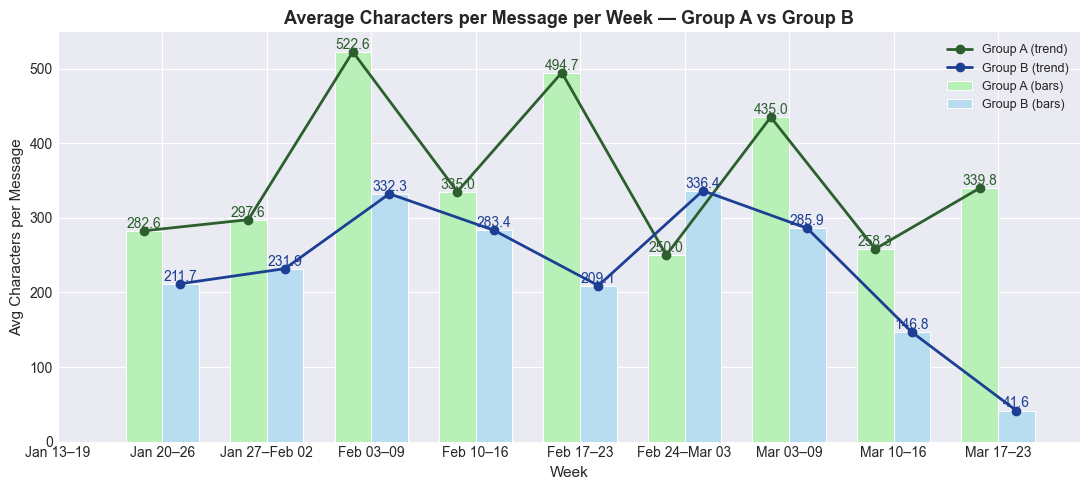

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# --- Define your weeks ---
weeks = [
    ('Jan 13–19',     'base_exports/base_usage_20260113_to_20260119.csv',  'db_exports/db_usage_20260113_to_20260119.csv'),
    ('Jan 20–26',     'base_exports/base_usage_20260120_to_20260126.csv',  'db_exports/db_usage_20260120_to_20260126.csv'),
    ('Jan 27–Feb 02', 'base_exports/base_usage_20260127_to_20260202.csv',  'db_exports/db_usage_20260127_to_20260202.csv'),
    ('Feb 03–09',     'base_exports/base_usage_20260203_to_20260209.csv',  'db_exports/db_usage_20260203_to_20260209.csv'),
    ('Feb 10–16',     'base_exports/base_usage_20260210_to_20260216.csv',  'db_exports/db_usage_20260210_to_20260216.csv'),
    ('Feb 17–23',     'base_exports/base_usage_20260217_to_20260223.csv',  'db_exports/db_usage_20260217_to_20260223.csv'),
    ('Feb 24–Mar 03',     'base_exports/base_usage_20260224_to_20260302.csv',  'db_exports/db_usage_20260224_to_20260302.csv'),
    ('Mar 03–09',     'base_exports/base_usage_20260303_to_20260309.csv',  'db_exports/db_usage_20260303_to_20260309.csv'),
    ('Mar 10–16',     'base_exports/base_usage_20260310_to_20260316.csv',  'db_exports/db_usage_20260310_to_20260316.csv'),
    ('Mar 17–23',     'base_exports/base_usage_20260317_to_20260323.csv',  'db_exports/db_usage_20260317_to_20260323.csv'),
]

# --- Colors ---
color_group_a = '#B8F0B8'
color_group_b = '#B8DCF0'
color_line_a  = '#2C5F2D'
color_line_b  = '#1C3F94'

# --- Load and aggregate ---
records = []
for week_label, path_a, path_b in weeks:
    df_a = pd.read_csv(path_a, encoding='latin-1')
    df_b = pd.read_csv(path_b, encoding='latin-1')
    records.append({
        'week':   week_label,
        'mean_a': df_a['avg_char_per_msg'].mean(),  # ← changed
        'mean_b': df_b['avg_char_per_msg'].mean(),  # ← changed
    })

df_plot = pd.DataFrame(records)

# --- Layout ---
week_labels = df_plot['week'].tolist()
x = np.arange(len(week_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

# Grouped bars
bars_a = ax.bar(x - bar_width / 2, df_plot['mean_a'], width=bar_width,
                color=color_group_a, edgecolor='white', linewidth=0.7, label='Group A (bars)', zorder=2)
bars_b = ax.bar(x + bar_width / 2, df_plot['mean_b'], width=bar_width,
                color=color_group_b, edgecolor='white', linewidth=0.7, label='Group B (bars)', zorder=2)

# Trend lines connecting bar tops
ax.plot(x - bar_width / 2, df_plot['mean_a'], color=color_line_a, linewidth=2,
        marker='o', markersize=6, label='Group A (trend)', zorder=3)
ax.plot(x + bar_width / 2, df_plot['mean_b'], color=color_line_b, linewidth=2,
        marker='o', markersize=6, label='Group B (trend)', zorder=3)

# Value labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, color=color_line_a)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, color=color_line_b)

ax.set_xticks(x)
ax.set_xticklabels(week_labels, fontsize=10)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Avg Characters per Message', fontsize=11)                              # ← changed
ax.set_title('Average Characters per Message per Week — Group A vs Group B',          # ← changed
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig('avg_char_per_msg_by_week.png', dpi=150, bbox_inches='tight')             # ← changed
plt.show()